# CAMulator Exercises: CESM Tutorial: Summer 2026

#### **CAMulator** is a global, machine-learned autoregressive emulator trained with data from the Community Atmosphere Model. See the version 1 publication here: https://arxiv.org/pdf/2504.06007

Camulator was trained and is run using the [CREDIT package](https://github.com/NCAR/miles-credit/tree/main).

The exercises below walk you through running a one-year **control** simulation with prescribed SST, CO2, Sea Ice, and Solar Insolation. We then run one simulation with a +2K perturbation to the SST (everything else same as control), and a second simulation using climitological SST with an idealized Gaussian ENSO SST signature. We then investigate some dynamic response to these perturbations. 

Simulations require a GPU and take approximately 8-10 minutes per annual simulation. 

Run the cell below to link to a pre-installed environment. you **ONLY NEED TO RUN THIS ONCE**. After executing, wait a few moments, and you should then be able to select the `credit_cesm` environment (from the dropdown in the upper right corner) and then execute the remainder of the notebook.

In [ ]:
!conda config --add envs_dirs /glade/work/dgagne/credit_cesm_envs/  ## ONLY RUN ONCE

In [3]:
import os, sys, glob, subprocess, shlex
from pathlib import Path
import os, pty, select
import yaml
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

## 1. Helpers

Address config keys by dotted path, write a per-experiment config copy, list the forecast's years,
perturb the per-year forcing store, drive the CREDIT CLI, and load rollouts back.

In [4]:
def write_config(overrides: dict, out_path: Path) -> Path:
    """Deep-copy BASE_CONFIG, apply {dotted_key: value} overrides, dump to out_path.

    Also injects the run options set in the "Run options" cell below: the output variable list
    (SAVE_VARS, always) and — only when RUN_MODE == 'batch' — the editable PBS options
    (PBS_OPTIONS). Locked pbs keys (conda / job_name / ncpus / ngpus) are left exactly as-is.
    """
    with open(BASE_CONFIG) as f:
        conf = yaml.safe_load(f)
    for dotted, value in overrides.items():
        set_by_path(conf, dotted, value)
    # user-selected output variables (short names -> full "CESM/.../<short>" keys)
    set_by_path(conf, 'inference.output.variables', [{'name': SHORT_TO_FULL[s]} for s in SAVE_VARS])
    # batch: apply the editable PBS options (credit submit reads the pbs: section)
    if RUN_MODE == 'batch':
        conf.setdefault('pbs', {}).update(PBS_OPTIONS)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, 'w') as f:
        yaml.safe_dump(conf, f, sort_keys=False)
    return out_path


def forecast_years(start_datetime, length) -> list:
    """Years the forecast window spans (dynamic forcing is one Zarr per year), so we only perturb
    the files actually read. Follows the selected start year + forecast_length."""
    start = pd.Timestamp(start_datetime)
    end = start + pd.Timedelta(length)
    return list(range(start.year, end.year + 1))
    

# Encoding keys inherited from the source Zarr that clash with a fresh (v3) write.
_STRIP_ENC = ("chunks", "preferred_chunks", "compressor", "compressors",
              "filters", "codecs", "serializer")

def perturb_forcing(src_template: str, dst_dir: Path, years, edit_fn) -> str:
    """Write a perturbed copy of the per-year forcing store.

    For each year in `years`, read the control `forcing_%Y.zarr`, apply edit_fn(ds)->ds, and
    write a perturbed `forcing_<year>.zarr` into dst_dir — preserving the `forcing_%Y.zarr`
    naming so the config's `%Y` template still resolves. Time is chunked by 1 (full otherwise)
    to keep the rollout's per-step reads cheap. Returns the dst path *template* (with `%Y`).

    Only the dynamic-forcing fields are touched; the prognostic initial condition still comes
    from the config's (unchanged) prognostic store, so every run starts from the same state.
    """
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    for y in years:
        ds = xr.open_zarr(src_template.replace('%Y', str(y))).load()
        ds = edit_fn(ds)
        ds = ds.chunk({'time': 1, **{d: -1 for d in ds.dims if d != 'time'}})
        for v in ds.variables:                       # drop inherited encoding (chunks/codecs)
            for k in _STRIP_ENC:
                ds[v].encoding.pop(k, None)
        out = dst_dir / f'forcing_{y}.zarr'
        ds.to_zarr(out, mode='w')
        print(f'  wrote {out}')
    return str(dst_dir / 'forcing_%Y.zarr')


# --- the actual interventions (one field each; everything else stays at control) ---
def add_sst(delta_k):
    """Uniform SST warming: SST -> SST + delta_k everywhere, all times."""
    def _edit(ds):
        # ds['SST'] = ds['SST'] + float(delta_k)
        ds['SST'].values = np.where(ds['SST'].values != 283, ds['SST'].values + float(delta_k), ds['SST'].values) # only apply over ocean
        return ds
    return _edit

def scale_co2(factor):
    """CO2 increase: co2vmr_3d -> factor * co2vmr_3d (e.g. 2.0 = doubling)."""
    def _edit(ds):
        ds['co2vmr_3d'] = ds['co2vmr_3d'] * float(factor)
        return ds
    return _edit

def run_credit(config_path: Path, mode='none', procs=4):
    """Run the rollout, interactively on THIS node or as a submitted PBS batch job.

    RUN_MODE == 'interactive' -> `credit rollout` on this node's GPU (needs a GPU here).
    RUN_MODE == 'batch'       -> `credit submit --mode rollout --cluster casper`, which builds a
                                 PBS job from the config's pbs: section and submits it via qsub.

    Output is forwarded through a pseudo-terminal (pty) so CREDIT's tqdm bar refreshes a single
    line interactively; in batch mode this just streams the submission / job-id output.
    """
    if RUN_MODE == 'batch':
        cmd = f'credit submit --mode rollout --cluster casper -c {shlex.quote(str(config_path))}'
    else:
        cmd = f'{CREDIT_CLI} -c {shlex.quote(str(config_path))} -m {mode} -p {procs}'
    print('$', cmd, flush=True)
    main, worker = pty.openpty()
    proc = subprocess.Popen(shlex.split(cmd), stdout=worker, stderr=worker, close_fds=True)
    os.close(worker)  # parent only reads the main end
    try:
        while True:
            if select.select([main], [], [], 0.1)[0]:
                try:
                    data = os.read(main, 1024)
                except OSError:  # main closes when the child exits
                    break
                if not data:
                    break
                sys.stdout.write(data.decode(errors='replace'))
                sys.stdout.flush()
            elif proc.poll() is not None:
                break
    finally:
        os.close(main)
        proc.wait()

    if proc.returncode != 0:
        raise RuntimeError(f'command exited with code {proc.returncode}')
    return proc.returncode

def load_rollout(output_dir, year=None, variables=None):
    """Open the NetCDF rollout (monthly files per the config) as one time-ordered dataset.

    year:      keep only files for that valid year (files are named YYYY-MM.nc) — use when a run
               spans more than one year so you don't open the whole rollout.
    variables: subset to these (those that exist) before returning, so a later .load() reads only
               what you actually need.
    """
    files = sorted(glob.glob(os.path.join(str(output_dir), '**', '*.nc'), recursive=True))
    if year is not None:
        files = [f for f in files if os.path.basename(f).startswith(f'{year}')]
    if not files:
        raise FileNotFoundError(f'No .nc files (year={year}) under {output_dir}')
    ds = xr.open_mfdataset(files, combine='by_coords')
    if variables is not None:
        present = [v for v in variables if v in ds.variables]
        missing = set(variables) - set(present)
        if missing:
            print(f'  (note: not in output, skipped: {sorted(missing)})')
        ds = ds[present]
    return ds

def global_mean(da, lat_name='latitude'):
    """Cosine-latitude-weighted global mean, collapsing lat/lon."""
    lat = da[lat_name]
    w = np.cos(np.deg2rad(lat))
    lon_name = 'lon' if 'lon' in da.dims else [d for d in da.dims if d not in (lat_name,)][ -1]
    return da.weighted(w).mean(dim=[lat_name, lon_name])

def get_by_path(d, dotted):
    for k in dotted.split('.'):
        d = d[k]
    return d

def set_by_path(d, dotted, value):
    keys = dotted.split('.')
    for k in keys[:-1]:
        d = d[k]
    d[keys[-1]] = value


### NOT USER EDITS ###
BASE_CONFIG = Path('/glade/campaign/cisl/aiml/credit/cesm_exercise//camulator_cesm_tutorial_casper.yml')

# Unified CREDIT CLI. `credit rollout` -> credit/applications/rollout_gen2.py.
CREDIT_CLI = 'credit rollout'

# Dotted keys into the config.
SAVE_LOC_KEY    = 'save_loc'
DYN_FORCING_KEY = 'data.source.CESM.variables.dynamic_forcing.path'
OUTPUT_KEY      = 'inference.save_forecast'
FCST_START_KEY  = 'inference.single_forecast.start_datetime'
FCST_LEN_KEY    = 'inference.single_forecast.forecast_length'

# --- derive paths from the config ------------------------------------------------------
with open(BASE_CONFIG) as f:
    CONF = yaml.safe_load(f)

ROLLOUT_ROOT = Path(os.path.expandvars(get_by_path(CONF, OUTPUT_KEY)))   # .../camulator_tutorial/rollout
RUN_ROOT     = ROLLOUT_ROOT.parent                                       # .../camulator_tutorial
FORCING_ROOT = RUN_ROOT / 'forcing'                                      # perturbed forcing (sibling of rollout)

# Shared, read-only control forcing (a %Y forcing template): read from, never written to.
CONTROL_FORCING = os.path.expandvars(get_by_path(CONF, DYN_FORCING_KEY))

for p in (RUN_ROOT, FORCING_ROOT, ROLLOUT_ROOT):
    p.mkdir(parents=True, exist_ok=True)

print('Config          :', BASE_CONFIG, '(exists:', BASE_CONFIG.exists(), ')')
print('Output base     :', RUN_ROOT, '(from inference.save_forecast)')
print('  rollout/      :', ROLLOUT_ROOT)
print('  forcing/      :', FORCING_ROOT)
print('Control forcing :', CONTROL_FORCING)

Config          : /glade/work/cbecker/CREDIT-visit/miles-credit/config/gen_2/camulator/camulator_cesm_tutorial_casper.yml (exists: True )
Output base     : /glade/derecho/scratch/cbecker/camulator_tutorial (from inference.save_forecast)
  rollout/      : /glade/derecho/scratch/cbecker/camulator_tutorial/rollout
  forcing/      : /glade/derecho/scratch/cbecker/camulator_tutorial/forcing
Control forcing : /glade/campaign/cisl/aiml/credit/cesm_exercise/forcing/dynamic_forcing/%Y_forcing.zarr


## Run options

Four knobs, applied automatically whenever an experiment cell builds its config.

**1 — Simulation year (`SIM_YEAR`).** Valid **1980–2014**. Sets `single_forecast.start_datetime` to `<year>-01-01`; the forecast length stays whatever the config specifies.

**2 — How to run (`RUN_MODE`).**
- `'interactive'` *(default)* — runs `credit rollout` on **this** node; needs a GPU here.
- `'batch'` — submits a PBS job with `credit submit --mode rollout --cluster casper`, built from the config's `pbs:` section. Use this if you don't have an interactive GPU; the output is the submitted job id (check it with `qstat`).

**3 — PBS options (`PBS_OPTIONS`, batch only).** Pre-filled from the config; edit `walltime`, `mem`, `gpu_type`, `project` as needed. **Locked** (not exposed): `conda`, `job_name`, `ncpus`, `ngpus`.

**4 — Output variables (`SAVE_VARS`).** Short names from the table below; the default matches the config's current set. Fewer variables → smaller, faster output. **3-D fields (`U`, `V`, `T`, `Qtot`) are large.**

### Available variables
| short | dims | description | units |
|-------|:----:|-------------|-------|
| `U` | 3D | Zonal wind | m/s |
| `V` | 3D | Meridional wind | m/s |
| `T` | 3D | Temperature | K |
| `Qtot` | 3D | Specific total water (vapor + condensate) | kg/kg |
| `PS` | 2D | Surface pressure | Pa |
| `TREFHT` | 2D | 2 m reference-height temperature | K |
| `PRECT` | 2D | Total precipitation (accumulated) | m/6h · ×4000 = mm/day |
| `TS` | 2D | Surface (radiative) temperature | K |
| `CLDHGH` | 2D | High cloud fraction | 0–1 |
| `CLDLOW` | 2D | Low cloud fraction | 0–1 |
| `CLDMED` | 2D | Mid-level cloud fraction | 0–1 |
| `TAUX` | 2D | Zonal surface wind stress | N/m² |
| `TAUY` | 2D | Meridional surface wind stress | N/m² |
| `U10` | 2D | 10 m wind speed | m/s |
| `QFLX` | 2D | Surface moisture flux (accumulated) | m/6h |
| `FSDS_J` | 2D | Downwelling shortwave at surface (accum.) | J/m²/6h · ÷21600 = W/m² |
| `FLDS_J` | 2D | Downwelling longwave at surface (accum.) | J/m²/6h |
| `FSUS` | 2D | Upwelling shortwave at surface (accum.) | J/m²/6h |
| `FLUS` | 2D | Upwelling longwave at surface (accum.) | J/m²/6h |
| `SHFLX` | 2D | Surface sensible heat flux (accum.) | J/m²/6h |
| `LHFLX` | 2D | Surface latent heat flux (accum.) | J/m²/6h |
| `FSUTOA` | 2D | Upwelling solar flux at top of atmosphere | W/m² |
| `FLUT` | 2D | Upwelling longwave at top of model (OLR) | W/m² |

In [8]:
# =========================== RUN OPTIONS =====================================
# 1) Which year to simulate (valid 1980-2014). Sets single_forecast.start_datetime = <year>-01-01;
#    the forecast length stays whatever the config specifies.
SIM_YEAR = 1995
START_DATETIME  = f'{SIM_YEAR}-01-01T00:00Z'
FORECAST_LENGTH = get_by_path(CONF, FCST_LEN_KEY)   # config-derived, e.g. '30d' / '364d'

# 2) How to run: 'interactive' runs `credit rollout` on THIS node (needs a GPU here);
#    'batch' submits a PBS job via `credit submit --mode rollout --cluster casper`
#    (which builds the job from the config's pbs: section below).
RUN_MODE = 'interactive'          # 'interactive' | 'batch'

# 3) PBS options for batch. Defaults pulled from the config's pbs: section; the locked keys
#    (conda / job_name / ncpus / ngpus) are not exposed. Edit before submitting, e.g.
#        PBS_OPTIONS['walltime'] = '01:00:00'
_PBS_LOCKED = {'conda', 'job_name', 'ncpus', 'ngpus'}
PBS_OPTIONS = {k: v for k, v in (get_by_path(CONF, 'pbs') or {}).items() if k not in _PBS_LOCKED}

# 4) Which variables to save (short names; see the "Available variables" table above).
#    Default = the config's current set. Fewer vars -> smaller, faster output. 3-D fields are big.
SAVE_VARS = ['Qtot', 'PS', 'TREFHT', 'PRECT', 'CLDHGH', 'TAUX', 'SHFLX', 'LHFLX']

# short-name -> full output key ("CESM/<group>/<dim>/<short>"), built from the config's var groups
_VARS = get_by_path(CONF, 'data.source.CESM.variables')
SHORT_TO_FULL = {v: f'CESM/{grp}/{dim}/{v}'
                 for grp in ('prognostic', 'diagnostic')
                 for dk, dim in (('vars_3D', '3d'), ('vars_2D', '2d'))
                 for v in (_VARS.get(grp, {}).get(dk) or [])}

_bad = [v for v in SAVE_VARS if v not in SHORT_TO_FULL]
assert not _bad, f'Unknown variable(s) {_bad}. Available: {sorted(SHORT_TO_FULL)}'

print('SIM_YEAR    :', SIM_YEAR, '->', START_DATETIME, '| length', FORECAST_LENGTH)
print('RUN_MODE    :', RUN_MODE)
print('PBS_OPTIONS :', PBS_OPTIONS, '  (batch only)')
print('SAVE_VARS   :', SAVE_VARS)

SIM_YEAR    : 1999 -> 1999-01-01T00:00Z | length 364d
RUN_MODE    : batch
PBS_OPTIONS : {'project': 'NAML0001', 'walltime': '00:30:00', 'mem': '64GB', 'gpu_type': 'h100'}   (batch only)
SAVE_VARS   : ['Qtot', 'PS', 'TREFHT', 'PRECT', 'CLDHGH', 'TAUX', 'SHFLX', 'LHFLX']


## 2. Control run

The origianl baseline everything is differenced against. Uses the shared control forcing **untouched** —
we only redirect the output to `/glade/derecho/$USER/camulator_tutorial/rollout/control/`.

In [ ]:
EXPERIMENT = 'control'
control_out = ROLLOUT_ROOT / EXPERIMENT

# Control forcing is left as-is (shared, read-only); we redirect output and set the sim year.
control_cfg = write_config(
    overrides={
        OUTPUT_KEY: str(control_out) + '/',
        FCST_START_KEY: START_DATETIME,
    },
    out_path=control_out / 'config.yml',
)

run_credit(control_cfg)

$ credit submit --mode rollout --cluster casper -c /glade/derecho/scratch/cbecker/camulator_tutorial/rollout/control/config.yml
INFO:credit.cli._submit:
  Ensemble rollout plan
  Cluster        : casper
  Account        : NAML0001
  Config         : /glade/derecho/scratch/cbecker/camulator_tutorial/rollout/control/config.yml
  Init times     : 1  (1 per job)
  Ensemble size  : 1  →  1 total forecasts
  Parallel jobs  : 1  (all start at once, no dependencies)
  GPUs per job   : 1
  Walltime/job   : 00:30:00


## 3. Experiment A — uniform SST warming (+2 K)

**Intervention:** `SST +2K` over the ocean, all times (CO2/ice/solar untouched).

**Expectation:** a moister atmosphere (precipitable water ≈ +7%/K) but weaker precip response(≈ +1–3%/K). 

In [22]:
EXPERIMENT = 'sst_plus2K'
DELTA_SST = 2.0  # K
years = forecast_years(START_DATETIME, FORECAST_LENGTH)
print('Perturbing forcing years:', years)

# 1) perturbed forcing copy -> forcing/<experiment>/forcing_%Y.zarr
sst_forcing = perturb_forcing(
    src_template=CONTROL_FORCING,
    dst_dir=FORCING_ROOT / EXPERIMENT,
    years=years,
    edit_fn=add_sst(DELTA_SST),
)

# 2) config copy: perturbed forcing, output dir, and the selected sim year
sst_cfg = write_config(
    overrides={
        DYN_FORCING_KEY: sst_forcing,
        OUTPUT_KEY: str(ROLLOUT_ROOT / EXPERIMENT) + '/',
        FCST_START_KEY: START_DATETIME,
    },
    out_path=ROLLOUT_ROOT / EXPERIMENT / 'config.yml',
)

# 3) run
run_credit(sst_cfg)

Perturbing forcing years: [1995]


/glade/work/cbecker/conda-envs/credit-aiml/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  wrote /glade/derecho/scratch/cbecker/camulator_tutorial/forcing/sst_plus2K/forcing_1995.zarr
$ credit rollout -c /glade/derecho/scratch/cbecker/camulator_tutorial/rollout/sst_plus2K/config.yml -m none -p 4
INFO:credit.datasets.schema:Loading channel schema from /glade/campaign/cisl/aiml/credit/cesm_exercise/channel_schema.yaml
<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
INFO:credit.models:Loading the CAMulator model with a conv decoder head and skip connections ...
INFO:credit.models.base_model:Loading a model with pre-trained weights from path /glade/campaign/cisl/aiml/credit/cesm_exercise/checkpoint.pt
INFO:credit.models.camulator:Adding spectral norm to all conv and linear layers
INFO:credit.models.checkpoint:All keys matched successfully
INFO:credit.datasets.multi_source:MultiSourceDataset: registered dataset 'CESM' with class 'LocalDataset'
INFO:rollout_gen2:Ra

0

## 4. Comparisons

Load into memory — only the year and variables the plots + CC diagnostic need. Depending on the amount of variables selected, this could take a few minutes.

A few diagnostics are presented from the existing control vs SST+2K runs. Spin-up (first month) is dropped.

1. **Zonal-mean Warming and Precipitation Distributions** `ΔTREFHT` vs latitude: a uniform +2 K SST does **not** give uniform
   surface warming (structure / polar amplification).
2. **Atmospheric Moisture Budget with mean warming** Clausius–Clapeyron (~7 %/K)

In [88]:
%%time
LOAD_YEAR = SIM_YEAR                    # which simulated year to analyze
LIGHT_VARS  = ['TREFHT', 'PRECT', 'PS', 'Qtot']       # small 2-D fields (plots + precip) -> load into memory
STREAM_VARS = []            # used only by the PW integral -> keep LAZY so it streams
NEEDED_VARS = LIGHT_VARS + STREAM_VARS

ctrl = load_rollout(ROLLOUT_ROOT / 'control',    year=LOAD_YEAR, variables=NEEDED_VARS).load()
sst  = load_rollout(ROLLOUT_ROOT / 'sst_plus2K', year=LOAD_YEAR, variables=NEEDED_VARS).load()

CPU times: user 3.05 s, sys: 23.6 s, total: 26.7 s
Wall time: 46.8 s


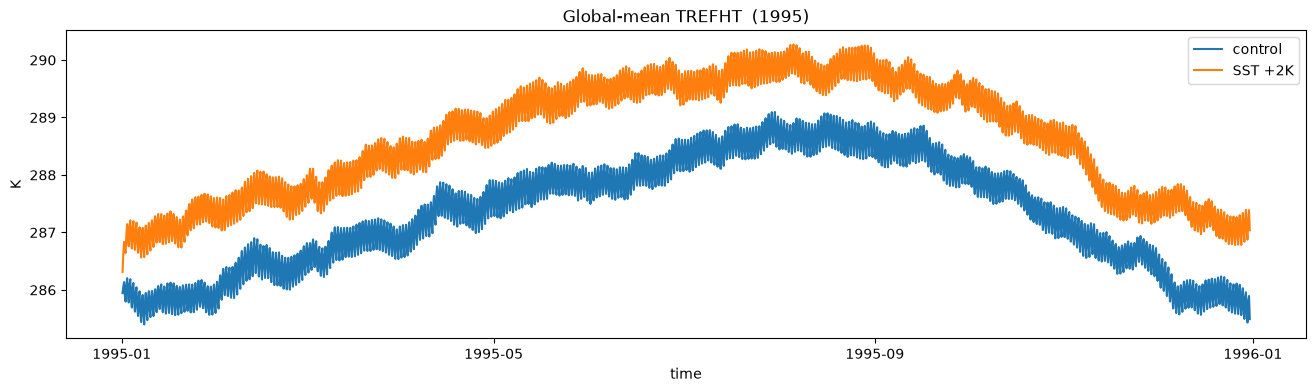

In [28]:
VAR = 'TREFHT'  # 2 m temperature (prognostic)

# --- global-mean time series -------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 4))
for ds, label in [(ctrl, 'control'), (sst, 'SST +2K')]:
    global_mean(ds[VAR]).plot(ax=ax, label=label)
ax.set_title(f'Global-mean {VAR}  ({LOAD_YEAR})')
ax.set_ylabel('K'); ax.legend(); plt.show()

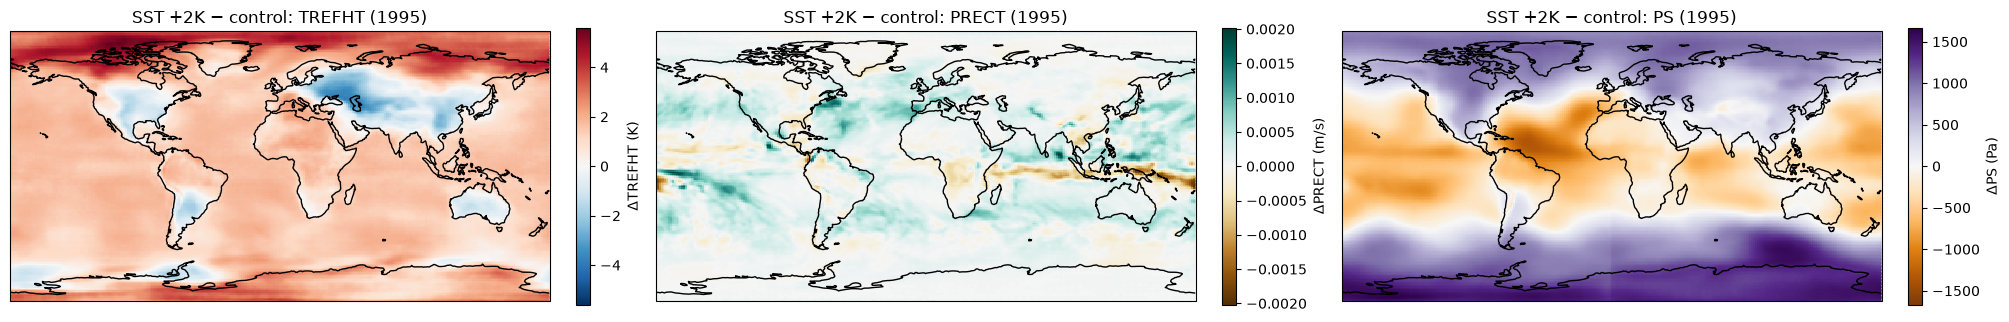

In [93]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

var_props = {
    'TREFHT': {'unit': 'K',   'cmap': 'RdBu_r'},
    'PRECT':  {'unit': 'm/s', 'cmap': 'BrBG'},   
    'PS':     {'unit': 'Pa',  'cmap': 'PuOr'}}    
variables = list(var_props.keys())

# 2. Calculate the difference (SST +2K - control) for all three variables
diff_arrays = [sst[var].mean('time') - ctrl[var].mean('time') for var in variables]

fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True, 
                         subplot_kw=dict(projection=ccrs.PlateCarree()))

for i, ax in enumerate(axes.ravel()):
    var = variables[i]
    unit = var_props[var]['unit']
    cmap = var_props[var]['cmap']
    
    diff_arrays[i].plot(ax=ax, cmap=cmap, center=0, transform=ccrs.PlateCarree(), cbar_kwargs={'label': f'Δ{var} ({unit})', 'shrink': 0.4})
    ax.set_title(f'SST +2K − control: {var} ({SIM_YEAR})')
    ax.coastlines()

plt.show()

## Clausius–Clapeyron water scaling (SST experiment)

Two numbers from the SST-warming run: column **water vapor** (precipitable water, from `Qtot`) should
rise ~7 %/K (via the Clausius–Clapeyron rate). 

Method: paired `pert − ctrl` (cancels common model drift), drop a spin-up, cosine-latitude-weighted
global mean, time-average, normalize by the *actual* global-mean warming (`ΔTREFHT`, < the 2 K imposed
over ocean). Precipitable water is a **mass-weighted** vertical integral of `Qtot`.

In [15]:
# Hybrid-sigma coefficients from the mass_fixer's statics file (config-derived), loaded once as
# float32 so the column integral stays float32 (avoids a float64 memory blow-up).
STATICS_PHYSICS = get_by_path(CONF, 'postblocks.per_step.mass_fixer.args.save_loc_physics')
_ST = xr.open_dataset(STATICS_PHYSICS)

_HYAI = _ST['hyai'].astype('float32').load()          # interface hybrid coeffs (length nlev+1)
_HYBI = _ST['hybi'].astype('float32').load()
_ILEV = _HYAI.dims[0]                                 # interface dim name, auto-detected (e.g. 'ilev')
_G  = 9.80665                                         # Gravity
_P0 = 100000.0   # Pa; CAM ref pressure


def precipitable_water(ds, q_var='Qtot', ps_var='PS', lev='level'):
    """Mass-weighted column water: PW = (1/g) Σ q_k Δp_k  [kg/m² == mm].

    Δp from the hybrid interfaces p = hyai*P0 + hybi*PS. NOT a plain level-sum. Stays float32 and,
    if Qtot/PS are lazy, stays lazy — so the reduction streams over the 3-D cube (bounded memory).
    """
    p_int = _HYAI * _P0 + _HYBI * ds[ps_var].astype('float32')     # (..., ilev)
    dp = abs(p_int.diff(_ILEV)).rename({_ILEV: lev}).transpose('time', 'level', ...)
    if lev in ds.coords:
        dp = dp.assign_coords({lev: ds[lev].values})
    return (ds[q_var].astype('float32') * dp).sum(lev) / _G


SPINUP_DAYS = 30   # discard atmospheric adjustment (~water-vapor residence time)

def _after_spinup(da):
    return da.isel(time=slice(int(SPINUP_DAYS * 24 / 6), None))    # 6-hourly steps


def scaling_per_K(pert, ctrl):
    """Paired %/K for precip (PRECT) and precipitable water (Qtot column), normalized by the actual
    global-mean warming ΔT. Spin-up is sliced up front so the heavy integral runs on less data;
    differencing pert-ctrl cancels common model drift."""
    p, c = _after_spinup(pert), _after_spinup(ctrl)
    def gm(da): return float(global_mean(da).mean('time'))        # triggers the streaming compute
    dT = gm(p['TREFHT']) - gm(c['TREFHT'])
    def pct(fp, fc): return (gm(fp) - gm(fc)) / gm(fc) * 100
    return {
        'dT': dT,
        'precip_pct_per_K': pct(p['PRECT'], c['PRECT']) / dT,
        'pw_pct_per_K':     pct(precipitable_water(p), precipitable_water(c)) / dT,
    }

In [25]:
%%time
# Clausius–Clapeyron scaling for the SST-warming experiment (sst vs ctrl).
res = scaling_per_K(sst, ctrl)
n_avg = sst.time.size - int(SPINUP_DAYS * 24 / 6)
print(f"ΔT (global-mean TREFHT)    : {res['dT']:+.2f} K")
print(f"Precipitation scaling      : {res['precip_pct_per_K']:+.1f} %/K   (expect ~1-3)")
print(f"Precipitable-water scaling : {res['pw_pct_per_K']:+.1f} %/K   (expect ~7, Clausius-Clapeyron)")
print(f"(spin-up dropped: {SPINUP_DAYS} d | steps averaged: {n_avg})")

ΔT (global-mean TREFHT)    : +1.29 K
Precipitation scaling      : +11.3 %/K   (expect ~1-3)
Precipitable-water scaling : +8.7 %/K   (expect ~7, Clausius-Clapeyron)
(spin-up dropped: 30 d | steps averaged: 1336)
CPU times: user 27.5 s, sys: 34.5 s, total: 1min 1s
Wall time: 2min 27s


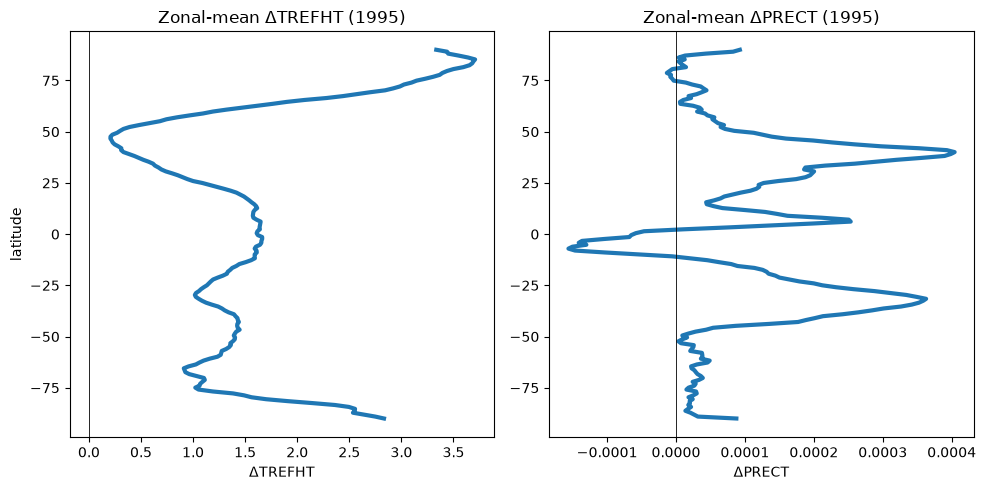

CPU times: user 857 ms, sys: 268 ms, total: 1.13 s
Wall time: 1.12 s


In [14]:
%%time
import matplotlib.pyplot as plt

# Define the two variables you want to plot side-by-side
variables = ['TREFHT', 'PRECT'] 

# Handle dimension names dynamically
LAT = 'latitude' if 'latitude' in ctrl.dims else 'lat'
LON = 'longitude' if 'longitude' in ctrl.dims else 'lon'

# Create a 1x2 grid of subplots with a wider figure size
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Loop through the variables and their corresponding axes
for i, var in enumerate(variables):
    ax = axes[i]
    
    # Calculate the time-mean anomaly, then the zonal mean
    diff_map = (_after_spinup(sst[var]).mean('time') 
              - _after_spinup(ctrl[var]).mean('time'))     # (lat, lon)
    diff_zonal = diff_map.mean(LON)                        # (lat,)

    # Plot on the specific axis
    diff_zonal.plot(ax=ax, y=LAT, linewidth=3)
    
    # Add the zero reference line
    ax.axvline(0, color='k', lw=0.6)
    
    # Dynamically label the x-axis and title based on the variable
    ax.set_xlabel(f'Δ{var}')
    ax.set_title(f'Zonal-mean Δ{var} ({LOAD_YEAR})')
    
    # Only label the y-axis (latitude) on the leftmost plot to keep it clean
    if i == 0:
        ax.set_ylabel('latitude')
    else:
        ax.set_ylabel('')

# Automatically adjust spacing so the plots don't overlap
plt.tight_layout()
plt.show()

In [48]:
# #2  Land vs ocean warming contrast. Land mask from the static LANDM_COSLAT (config-derived).
STATIC_PATH = os.path.expandvars(get_by_path(CONF, 'data.source.CESM.variables.static.path'))
_landm = xr.open_dataset(STATIC_PATH)['LANDM_COSLAT'].squeeze()
is_land = xr.DataArray(np.asarray(_landm.values) > 0.8, dims=(LAT, LON),
                       coords={LAT: ctrl[LAT], LON: ctrl[LON]})
_coslat = np.cos(np.deg2rad(ctrl[LAT]))
def _region_mean(da, region):
    return float(da.weighted((_coslat * region).fillna(0)).mean([LAT, LON]))

dT_land  = _region_mean(dT_map, is_land)      # dT_map from cell #1
dT_ocean = _region_mean(dT_map, ~is_land)
print(f'ΔTREFHT land   = {dT_land:+.2f} K')
print(f'ΔTREFHT ocean  = {dT_ocean:+.2f} K')


ΔTREFHT land   = +0.81 K
ΔTREFHT ocean  = +1.57 K


## 7. ENSO in a climatological world (idealized El Niño)

The runs above used the real, time-evolving SST for the chosen year, so whatever ENSO state that
year happened to be in is baked into *both* control and perturbation. To study ENSO cleanly we instead
start from a **climatological-SST** world — the mean seasonal cycle with interannual variability
(El Niño / La Niña) removed — and then impose a simplified idealized El Niño. 

**Two 1990 runs (everything prescribed; only SST differs; 1990 was a relatively Neutral ENSO):**

1. **`climo_control`**: 1990 forcing with SST replaced by climatology (`climo_sst_1990.zarr`). A
   "no-ENSO" baseline: the ocean carries only its mean seasonal cycle.
2. **`climo_enso`**: Same climatological forcing plus a Gaussian warm SST blob in the
   equatorial central-eastern Pacific.

**Potential Expectations from `climo_enso − climo_control`:**
- **Rain shifts east** - enhanced convection/precip over the central-eastern Pacific where we warmed
  the ocean, and *suppressed* rain over the Maritime Continent / western Pacific: a weakened **Walker
  circulation** and relaxed trade winds (`TAUX`). Higher precip in NW CONUS; less in SE CONUS
- **Southern Oscillation** -  Clear separation in the East and West Nodes (represented by `PS`)
- **Potential Teleconnections** — a Pacific–North American (PNA)-like wave train arcing into the extratropics:
  `TREFHT` / circulation anomalies far from the blob (e.g. over North America) — the tropics steering
  mid-latitude weather. 
- **Slight global-mean warming** (we added heat), but the *pattern* is the story, not the global mean.
- **Caveats** — CAMulator trained on *real* ENSO events, so an idealized Gaussian blob is somewhat
  out-of-distribution; read the teleconnection as *plausible*, not truth. And one year is a single
  realization, so expect internal-variability noise in the extratropical response.

These runs are for **1990** (independent of `SIM_YEAR` above)

In [5]:
# --- Climatological-SST control for 1990 -----------------------------------------------
CLIMO_YEAR    = 1990
CLIMO_START   = f'{CLIMO_YEAR}-01-01T00:00Z'
CLIMO_FORCING = '/glade/campaign/cisl/aiml/credit/cesm_exercise/forcing/dynamic_forcing/climo_sst_1990.zarr'

climo_ctrl_out = ROLLOUT_ROOT / 'climo_control'

# Replace the dynamic-forcing store with the climo-SST file (a single Zarr, no %Y), redirect the
# output, and set the 1990 start. Solar / sea ice / CO2 / initial condition are the config defaults.
climo_ctrl_cfg = write_config(
    overrides={
        DYN_FORCING_KEY: CLIMO_FORCING,
        OUTPUT_KEY: str(climo_ctrl_out) + '/',
        FCST_START_KEY: CLIMO_START,
    },
    out_path=climo_ctrl_out / 'config.yml',
)

run_credit(climo_ctrl_cfg)

$ credit rollout -c /glade/derecho/scratch/cbecker/camulator_tutorial/rollout/climo_control/config.yml -m none -p 4
INFO:credit.datasets.schema:Loading channel schema from /glade/campaign/cisl/aiml/credit/cesm_exercise/channel_schema.yaml
<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
INFO:credit.models:Loading the CAMulator model with a conv decoder head and skip connections ...
INFO:credit.models.base_model:Loading a model with pre-trained weights from path /glade/campaign/cisl/aiml/credit/cesm_exercise/checkpoint.pt
INFO:credit.models.camulator:Adding spectral norm to all conv and linear layers
INFO:credit.models.checkpoint:All keys matched successfully
INFO:credit.datasets.multi_source:MultiSourceDataset: registered dataset 'CESM' with class 'LocalDataset'
INFO:rollout_gen2:Rank 0/1: 1 init time(s), 1456 steps each
INFO:credit.trainers.rollout_utils:Forecast init: 19

0

#### El Niño blob intervention

Add a Gaussian warm SST anomaly (amplitude `ENSO_AMP` K) centered in the equatorial central-eastern
Pacific — elongated zonally (broad in longitude, narrow in latitude), like a real El Niño — on top of
the climatological SST, **ocean only** (the land fill is left untouched). Everything else is identical
to `climo_control`, so `climo_enso − climo_control` isolates the response to the anomaly we imposed.

In [7]:
# --- Idealized El Niño: Gaussian SST blob added on top of the climatological forcing ---
ENSO_AMP     = 3.0     # peak SST anomaly (K)
ENSO_LAT0    = 0.0     # center latitude (equator)
ENSO_LON0    = 210.0   # center longitude (~150 W, central-eastern Pacific; grid is 0-360)
ENSO_SIG_LAT = 7.5     # latitudinal width  (deg, std dev) -> narrow
ENSO_SIG_LON = 30.0    # longitudinal width (deg, std dev) -> broad / zonally elongated
LAND_FILL    = 283.0   # SST land-fill value in this dataset (ocean = SST != LAND_FILL)

def add_enso_blob(amp, lat0, lon0, sig_lat, sig_lon, land_fill=LAND_FILL):
    """Add a Gaussian warm SST anomaly (El Nino-like) over OCEAN only; other fields untouched."""
    def _edit(ds):
        latn = 'latitude' # if 'latitude'  in ds['SST'].dims else 'lat'
        lonn = 'longitude'# if 'longitude' in ds['SST'].dims else 'lon'
        blob = amp * np.exp(-0.5 * (((ds[latn] - lat0) / sig_lat) ** 2
                                    + ((ds[lonn] - lon0) / sig_lon) ** 2))   # (lat, lon)
        sst = ds['SST']
        ds['SST'] = xr.where(sst != land_fill, sst + blob, sst)             # ocean only; broadcasts over time
        return ds
    return _edit

# 1) perturbed forcing (climatological SST + blob) -> forcing/climo_enso/forcing_1990.zarr
enso_forcing = perturb_forcing(
    src_template=CLIMO_FORCING,             # single climo file; perturb rewrites the one year into USER dir
    dst_dir=FORCING_ROOT / 'climo_enso',
    years=[CLIMO_YEAR],
    edit_fn=add_enso_blob(ENSO_AMP, ENSO_LAT0, ENSO_LON0, ENSO_SIG_LAT, ENSO_SIG_LON),
)

# 2) config copy: perturbed forcing, its own output dir, 1990 start (everything else = climo_control)
enso_cfg = write_config(
    overrides={
        DYN_FORCING_KEY: enso_forcing,
        OUTPUT_KEY: str(ROLLOUT_ROOT / 'climo_enso') + '/',
        FCST_START_KEY: CLIMO_START,
    },
    out_path=ROLLOUT_ROOT / 'climo_enso' / 'config.yml',
)

# 3) run
run_credit(enso_cfg)

/glade/work/dgagne/credit_cesm_envs/credit_cesm/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  wrote /glade/derecho/scratch/cbecker/camulator_tutorial/forcing/climo_enso/forcing_1990.zarr
$ credit rollout -c /glade/derecho/scratch/cbecker/camulator_tutorial/rollout/climo_enso/config.yml -m none -p 4
INFO:credit.datasets.schema:Loading channel schema from /glade/campaign/cisl/aiml/credit/cesm_exercise/channel_schema.yaml
<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
INFO:credit.models:Loading the CAMulator model with a conv decoder head and skip connections ...
INFO:credit.models.base_model:Loading a model with pre-trained weights from path /glade/campaign/cisl/aiml/credit/cesm_exercise/checkpoint.pt
INFO:credit.models.camulator:Adding spectral norm to all conv and linear layers
INFO:credit.models.checkpoint:All keys matched successfully
INFO:credit.datasets.multi_source:MultiSourceDataset: registered dataset 'CESM' with class 'LocalDataset'
INFO:rollout_gen2:Ra

0

In [11]:
%%time
LOAD_YEAR = CLIMO_YEAR
LIGHT_VARS  = ['TREFHT', 'PRECT', 'PS']   
climo_ctrl = load_rollout(ROLLOUT_ROOT / 'climo_control',    year=LOAD_YEAR, variables=LIGHT_VARS).load()
climo_enso  = load_rollout(ROLLOUT_ROOT / 'climo_enso', year=LOAD_YEAR, variables=LIGHT_VARS).load()

CPU times: user 406 ms, sys: 1.08 s, total: 1.49 s
Wall time: 1.03 s


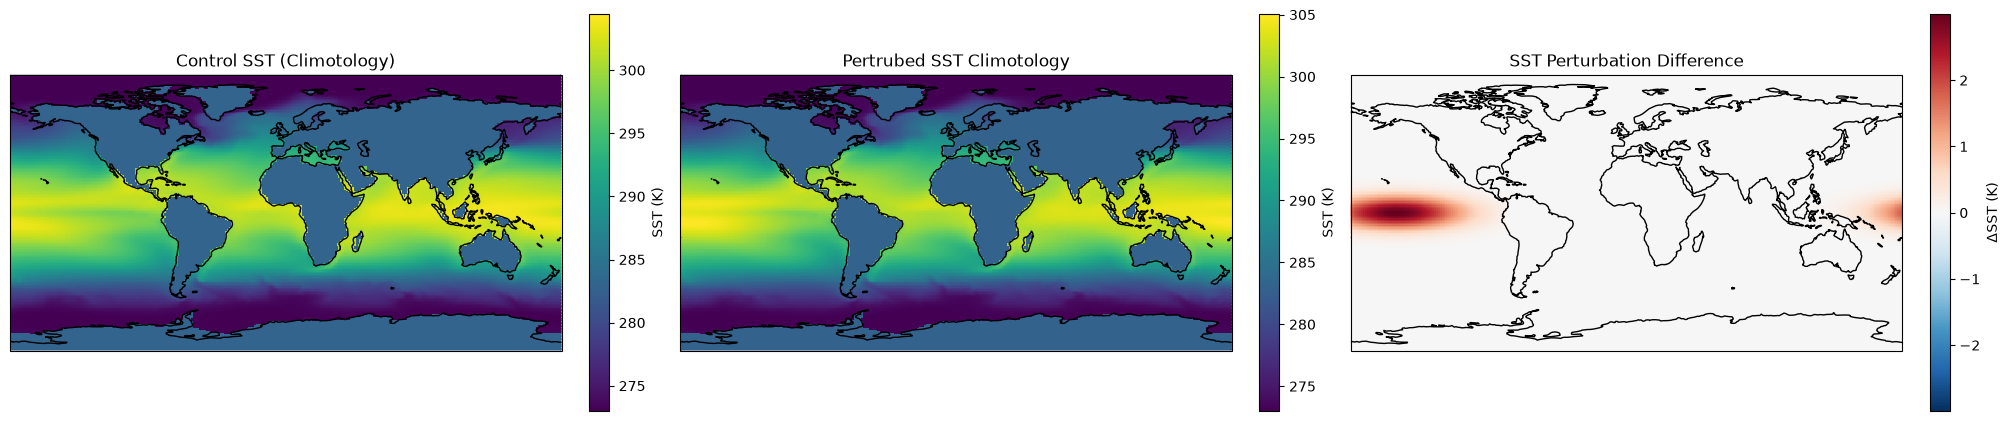

In [12]:
climo_sst = xr.open_dataset(CLIMO_FORCING.replace("%Y", "1990"))['SST'].mean('time') 
climo_enso_sst = xr.open_dataset(enso_forcing.replace("%Y", "1990"))['SST'].mean('time')
sst_diff = climo_enso_sst - climo_sst
arrays = [climo_sst, climo_enso_sst, sst_diff]
titles = ['Control SST (Climotology)', 'Pertrubed SST Climotology', 'SST Perturbation Difference']

fig, axes = plt.subplots(1, 3, figsize=(20, 10), constrained_layout=True, subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axes.ravel()):
    if i < 2:
        cmap = 'viridis' 
        center = None
        cbar_label = 'SST (K)'
    else:
        cmap = 'RdBu_r' 
        center = 0
        cbar_label = 'ΔSST (K)'
    arrays[i].plot(ax=ax, cmap=cmap, transform=ccrs.PlateCarree(), cbar_kwargs={'label': cbar_label, 'shrink': 0.4}, center=center)
    ax.set_title(titles[i])
    ax.coastlines()

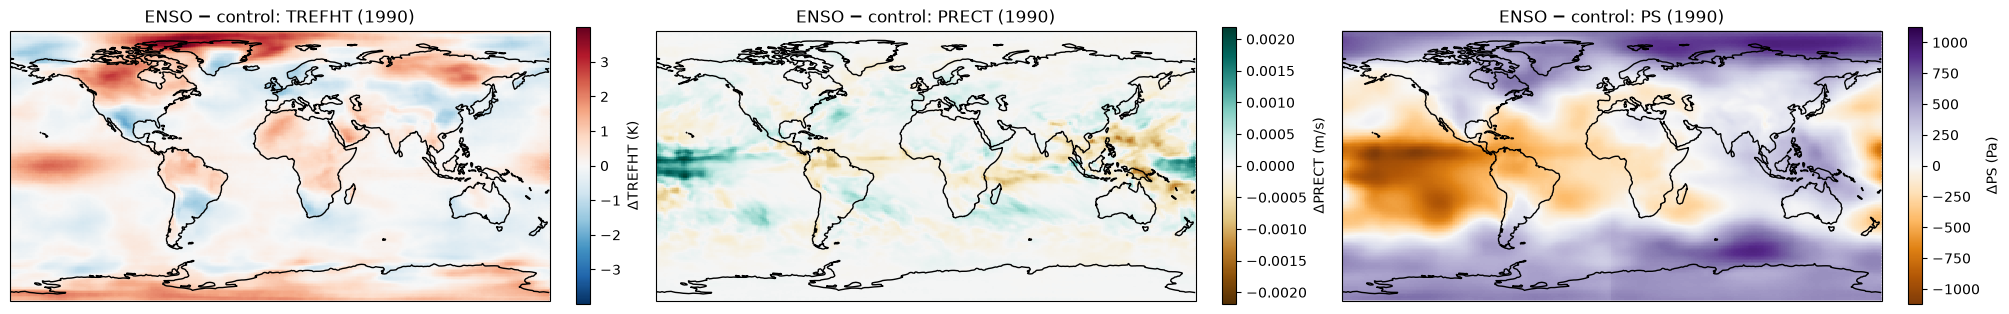

In [97]:
var_props = {
    'TREFHT': {'unit': 'K',   'cmap': 'RdBu_r'}, 
    'PRECT':  {'unit': 'm/s', 'cmap': 'BrBG'},   
    'PS':     {'unit': 'Pa',  'cmap': 'PuOr'}}
variables = list(var_props.keys())

# 2. Calculate the difference (ENSO - control) for all three variables
diff_arrays = [climo_enso[var].mean('time') - climo_ctrl[var].mean('time') for var in variables]

fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True, 
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axes.ravel()):
    var = variables[i]
    unit = var_props[var]['unit']
    cmap = var_props[var]['cmap']
    diff_arrays[i].plot(ax=ax, cmap=cmap,  center=0, transform=ccrs.PlateCarree(), cbar_kwargs={'label': f'Δ{var} ({unit})', 'shrink': 0.4})
    ax.set_title(f'ENSO − control: {var} ({LOAD_YEAR})')
    ax.coastlines()

plt.show()